In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("../data/raw/data.csv")

In [8]:
df.shape

(95662, 16)

In [9]:
df.shape
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [5]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [6]:
df.isnull().sum()

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

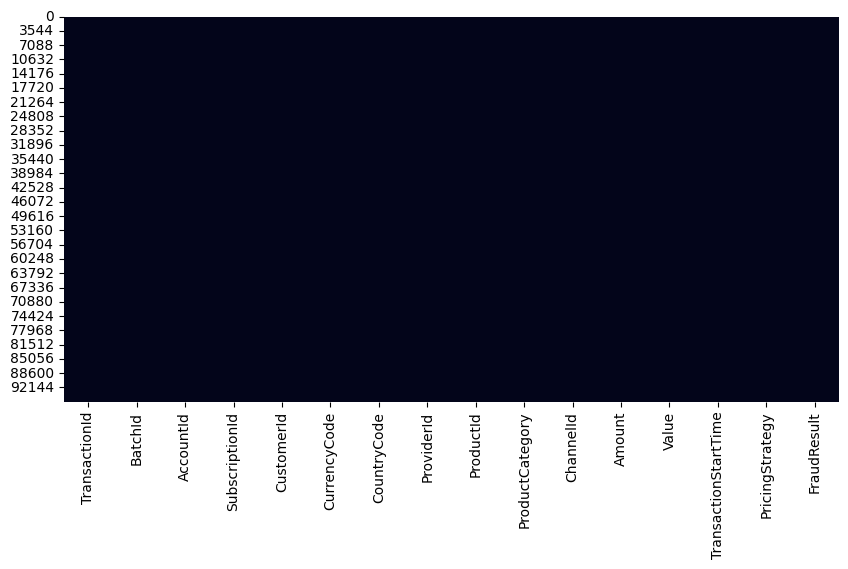

In [7]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.show()

Numerical Distributions

In [8]:
numerical_cols = [
    "Amount",
    "Value"
]

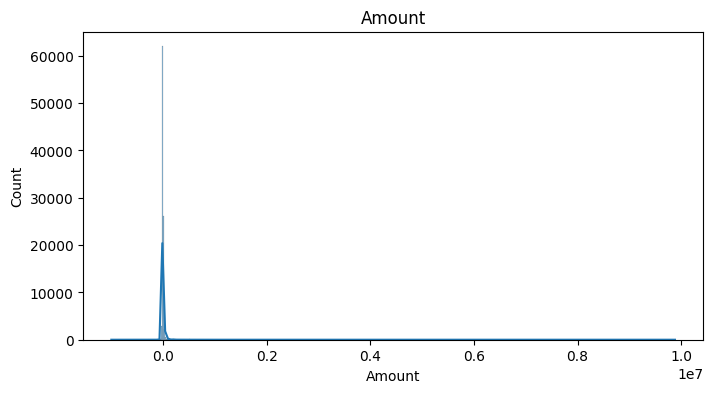

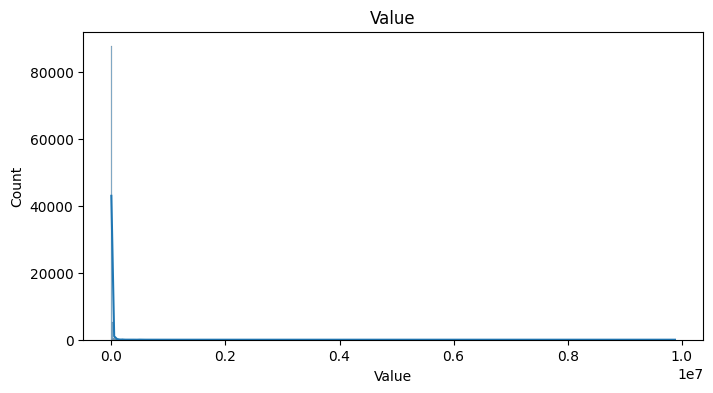

In [9]:
for col in numerical_cols:
    
    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

Categorical Distributions

In [10]:
df["ChannelId"].value_counts()

ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64

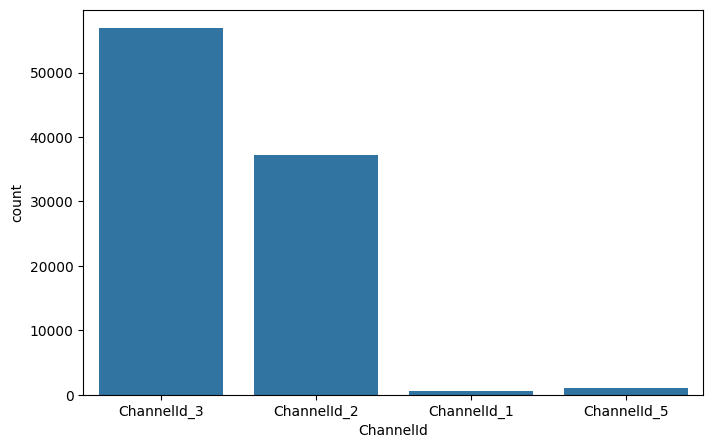

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="ChannelId",
    data=df
)

plt.show()

Correlation

In [13]:
corr = df[
    ["Amount","Value"]
].corr()

corr

,Amount,Value
Amount,1.000000,0.989692
Value,0.989692,1.000000


<Axes: >

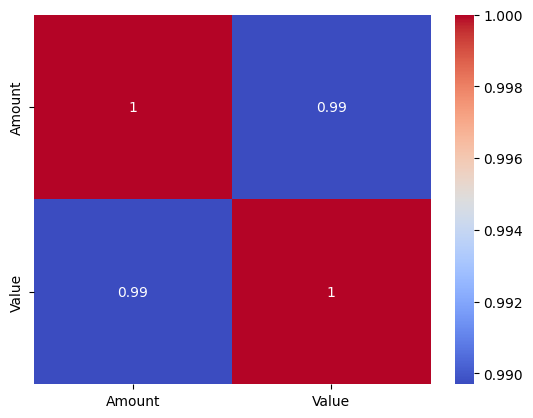

In [14]:
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

Outliers

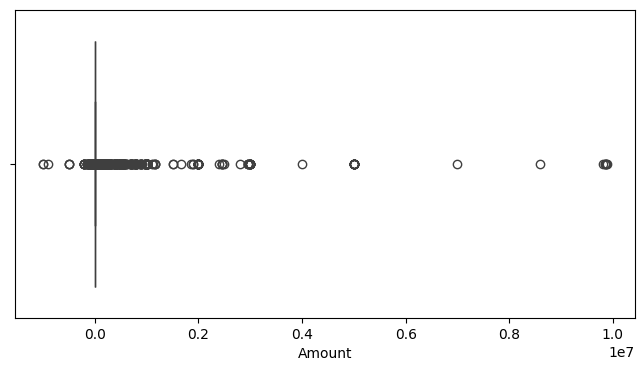

In [15]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["Amount"]
)

plt.show()

Fraud Analysis

In [16]:
df["FraudResult"].value_counts()

FraudResult
0    95469
1      193
Name: count, dtype: int64

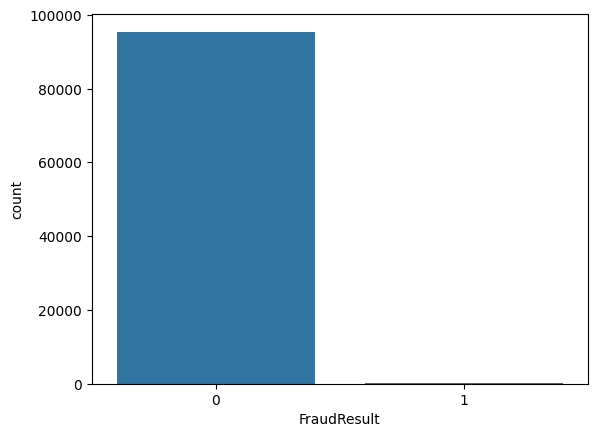

In [17]:
sns.countplot(
    x="FraudResult",
    data=df
)

plt.show()

Time Analysis

In [18]:
df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)

In [19]:
df["Year"] = df["TransactionStartTime"].dt.year
df["Month"] = df["TransactionStartTime"].dt.month
df["Day"] = df["TransactionStartTime"].dt.day
df["Hour"] = df["TransactionStartTime"].dt.hour

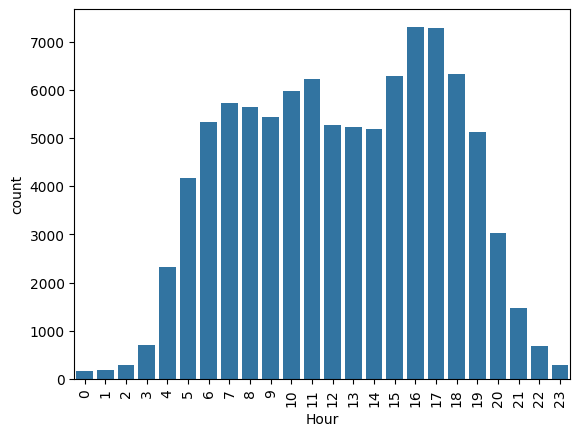

In [20]:
sns.countplot(
    x="Hour",
    data=df
)

plt.xticks(rotation=90)

plt.show()

# Key Insights

## 1. Large Transaction Dataset with Rich Behavioral Information
The dataset contains 95,662 transaction records and 16 features describing customer activity, transaction characteristics, channels, products, and fraud outcomes. This provides a strong foundation for customer behavior analysis and credit risk modeling.

## 2. Fraud Cases Are Extremely Rare
Only 193 transactions (approximately 0.2%) are labeled as fraudulent, while 95,469 transactions are non-fraudulent. This indicates a highly imbalanced target distribution and highlights the importance of using appropriate evaluation metrics when building predictive models.

## 3. Transaction Amounts Exhibit Significant Skewness and Outliers
Exploratory analysis of Amount and Value revealed highly skewed distributions with several extreme values. This suggests that scaling or transformation techniques may be necessary during feature engineering and model training.

## 4. Customer Activity Is Concentrated in Specific Product Categories and Channels
The distribution of ProductCategory and ChannelId shows that customer activity is not evenly distributed across categories and transaction channels. These variables are likely to contain useful behavioral signals for customer segmentation and risk assessment.

## 5. Transaction Timing May Provide Predictive Signals
Analysis of TransactionStartTime indicates variation in transaction activity across different hours and dates. Temporal features such as transaction hour, day, and month may capture behavioral patterns that contribute to credit risk prediction.